# 📊 EDA — Online Retail II Dataset

**Du an:** AI_BI_DASHBOARD  
**Nguon:** UCI Machine Learning Repository  
**Nguoi tao:** Dr. Daqing Chen, De Montfort University  
**Ngay tao notebook:** 2026-09-08  

---

## MUC LUC

1. [Thong tin file](#1-thong-tin-file)  
2. [Tong quan du lieu](#2-tong-quan-du-lieu)  
3. [Tu dien du lieu](#3-tu-dien-du-lieu)  
4. [Demo 5 dong dau](#4-demo-5-dong-dau)  
5. [Phan bo du lieu](#5-phan-bo-du-lieu)  
6. [Missing values & trung lap](#6-missing-values--trung-lap)  
7. [Ma tran tuong quan](#7-ma-tran-tuong-quan)  
8. [De xuat cleaning](#8-de-xuat-cleaning)  
9. [Tong ket executive summary](#9-tong-ket-executive-summary)

## 1. Thong tin file (File Metadata)

- **File:** `online_retail_II.xlsx`  
- **Vi tri:** `Dataset/Data/2. DỮ LIỆU TÀI CHÍNH DOANH NGHIỆP/online+retail+ii/online_retail_II.xlsx`  
- **Dung luong:** 43.51 MB (45,622,278 bytes)  
- **Nguon:** UCI Machine Learning Repository — Online Retail II Data Set  
- **Nguoi tao/cung cap:** Dr. Daqing Chen, School of Computer Science and Informatics, De Montfort University  
- **Ngay thu thap:** 01/12/2009 – 09/12/2011  
- **So sheet:** 2 (`Year 2009-2010`, `Year 2010-2011`)

## 2. Tong quan du lieu (Data Overview)

- **Tong dong (gop 2 sheet):** 1,067,371  
- **Tong cot:** 9  
- **Sheet 'Year 2009-2010':** 525,461 dong  
- **Sheet 'Year 2010-2011':** 541,910 dong

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10

FILE_PATH = r'../online_retail_II.xlsx'
xl = pd.ExcelFile(FILE_PATH)
dfs = []
for s in xl.sheet_names:
    df = pd.read_excel(xl, sheet_name=s)
    df['Sheet'] = s
    dfs.append(df)
df = pd.concat(dfs, ignore_index=True)

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head(5)


Shape: (1067371, 9)
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Sheet']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sheet
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,Year 2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Year 2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Year 2009-2010
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,Year 2009-2010
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,Year 2009-2010


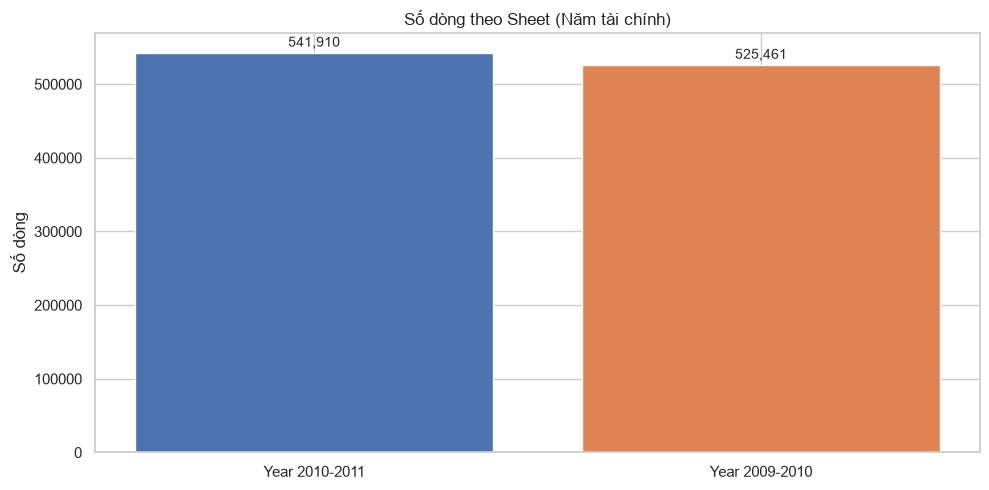

In [2]:
sheet_counts = df['Sheet'].value_counts()
fig, ax = plt.subplots()
ax.bar(sheet_counts.index, sheet_counts.values, color=['#4C72B0','#DD8452'])
ax.set_title('Số dòng theo Sheet (Năm tài chính)')
ax.set_ylabel('Số dòng')
for i, v in enumerate(sheet_counts.values):
    ax.text(i, v + 5000, f'{v:,}', ha='center', va='bottom')
plt.tight_layout()
plt.show()


## 3. Tu dien du lieu (Data Dictionary) — Cho Project AI_BI_DASHBOARD

| Cot | Kieu | Y nghia nghiep vu | Vai tro trong AI/BI Dashboard |
|-----|------|-------------------|-------------------------------|
| **Invoice** | string | Ma hoa don (co prefix 'C' = credit note/huy/tra hang) | Primary key giao dich; phan biet ban vs tra; join voi fact table |
| **StockCode** | string | Ma SKU san pham (5-6 ky tu, alphanumeric) | Dimension key san pham; segment theo nhom hang; input cho recommendation engine |
| **Description** | string | Ten mo ta san pham (tieng Anh) | Label hien thi UI; text analytics/NLP cho tim kiem, phan loai |
| **Quantity** | int64 | So luong (duong = ban, am = tra/huy) | Measure quan trong: doanh thu, ton kho, RFM frequency; outlier detection |
| **InvoiceDate** | datetime64 | Thoi diem giao dich (do chinh xac: phut) | Time dimension; trend analysis, seasonality, cohort, forecasting |
| **Price** | float64 | Don gia (GBP) tai thoi diem ban | Measure gia; price elasticity, margin analysis, anomaly detection |
| **Customer ID** | float64 (nullable) | Ma khach hang duy nhat (NaN = khach vang lai/guest) | **Critical** cho RFM, CLV, segmentation, churn prediction; ~23% missing |
| **Country** | string | Quoc gia giao hang/billing | Geo dimension; market expansion, shipping cost, localization |
| **Sheet** | string | Nam tai chinh (2009-2010 / 2010-2011) | Partition key; year-over-year comparison |

## 4. Demo 5 dong dau (Head)

Bang tren hien thi 5 dong mau. Ghi chu:

- Cung `Invoice` = cung hoa don nhieu mat hang  
- `Customer ID` co gia tri hop le khi khong phai khach vang lai  
- `Sheet` xac dinh nam tai chinh cua giao dich

## 5. Phan bo du lieu (Data Distribution)

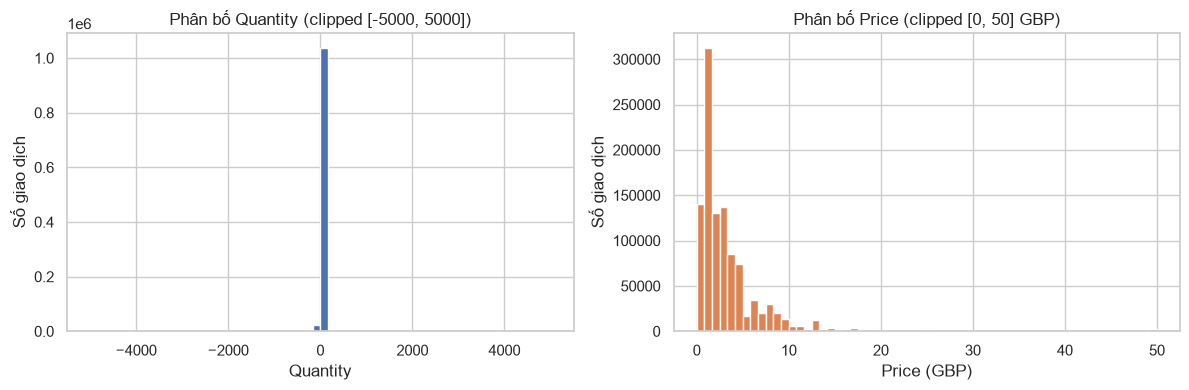

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

quantity = df['Quantity'].clip(-5000, 5000)
axes[0].hist(quantity, bins=60, color='#4C72B0', edgecolor='white')
axes[0].set_title('Phân bố Quantity (clipped [-5000, 5000])')
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('Số giao dịch')

price = df['Price'].clip(0, 50)
axes[1].hist(price, bins=60, color='#DD8452', edgecolor='white')
axes[1].set_title('Phân bố Price (clipped [0, 50] GBP)')
axes[1].set_xlabel('Price (GBP)')
axes[1].set_ylabel('Số giao dịch')

plt.tight_layout()
plt.show()


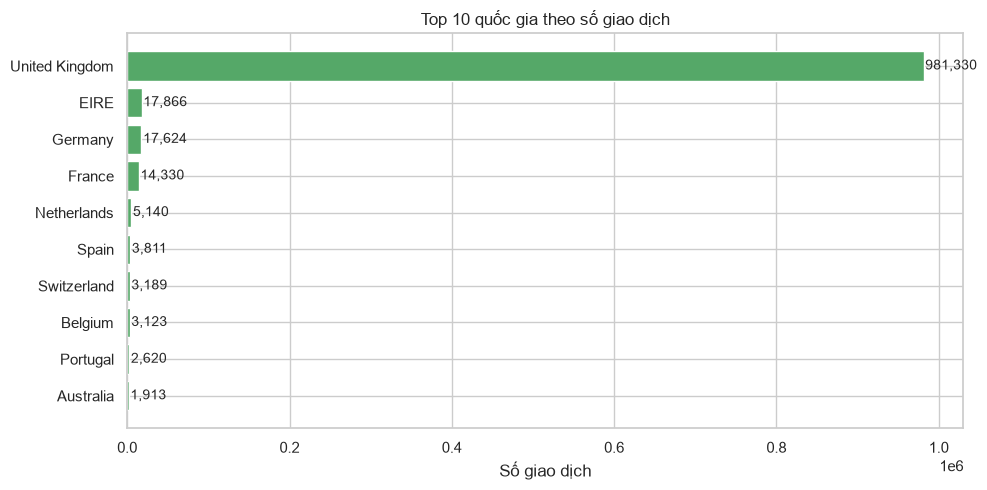

In [4]:
country_top = df['Country'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(country_top.index[::-1], country_top.values[::-1], color='#55A868')
ax.set_title('Top 10 quốc gia theo số giao dịch')
ax.set_xlabel('Số giao dịch')
for i, v in enumerate(country_top.values[::-1]):
    ax.text(v + 2000, i, f'{v:,}', va='center')
plt.tight_layout()
plt.show()


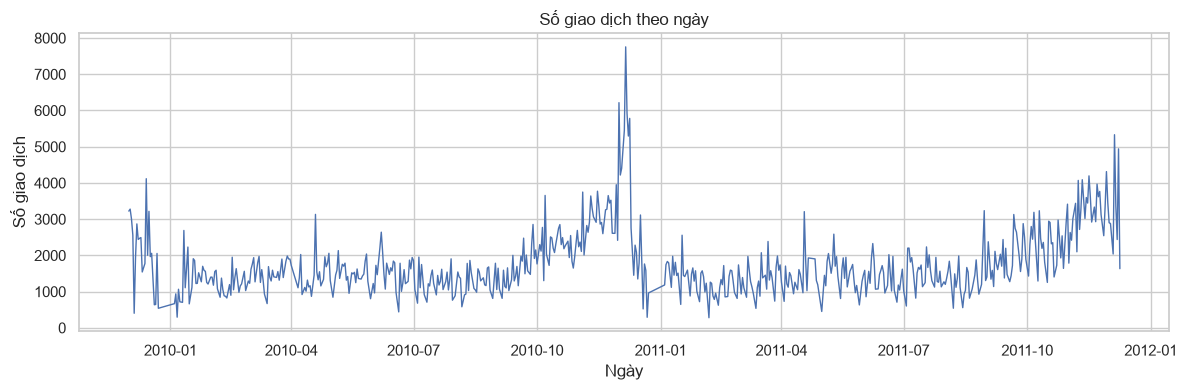

In [5]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
daily = df.groupby(df['InvoiceDate'].dt.date).size()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily.index, daily.values, color='#4C72B0', linewidth=1)
ax.set_title('Số giao dịch theo ngày')
ax.set_xlabel('Ngày')
ax.set_ylabel('Số giao dịch')
plt.tight_layout()
plt.show()


### Nhan xet phan bo:

- **Quantity:** Trung vi = 3, nhung max = 80,995 → co outlier cuc lon (co the la B2B/bulk order). Co gia tri am manh (-80,995).

- **Price:** Trung vi = 2.1 GBP, max = 38,970 → outlier gia cao; co gia ≤ 0 (POSTAGE, adjustment, test).

- **Country:** UK ap dao 91.9%; 43 quoc gia con lai chi chiem 8.1%.

- **Thoi gian:** 738 ngay (tu 01/12/2009 den 09/12/2011), 2 nam tai chinh.

## 6. Missing values & trung lap

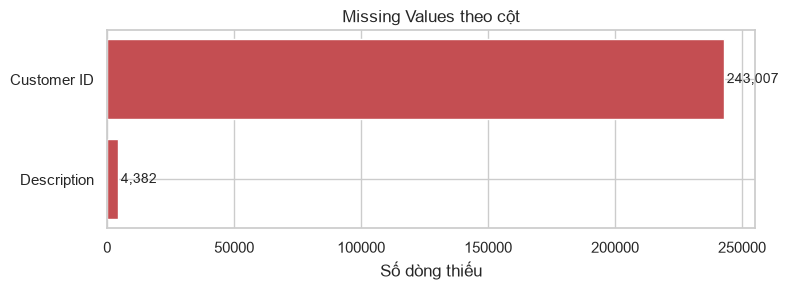

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(missing.index, missing.values, color='#C44E52')
ax.set_title('Missing Values theo cột')
ax.set_xlabel('Số dòng thiếu')
for i, v in enumerate(missing.values):
    ax.text(v + 1000, i, f'{v:,}', va='center')
plt.tight_layout()
plt.show()


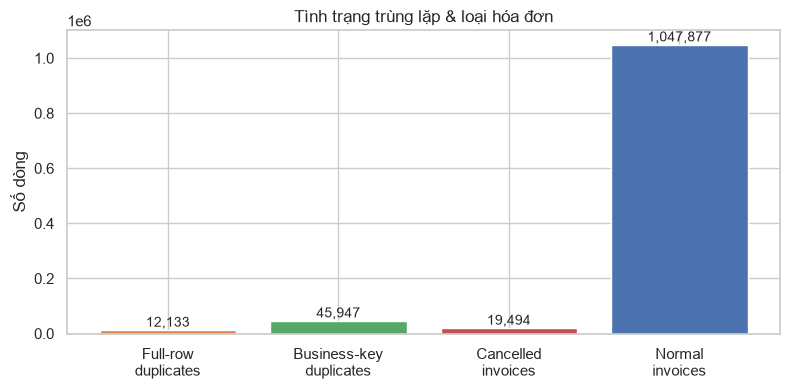

In [8]:
full_dup = df.duplicated().sum()
biz_dup = df.duplicated(subset=['Invoice', 'StockCode']).sum()
cancelled = df[df['Invoice'].astype(str).str.startswith('C')].shape[0]
normal = df[~df['Invoice'].astype(str).str.startswith('C')].shape[0]

# Thay bằng \n để ngắt dòng trong chuỗi
labels = ['Full-row\nduplicates', 'Business-key\nduplicates', 'Cancelled\ninvoices', 'Normal\ninvoices']
values = [full_dup, biz_dup, cancelled, normal]
colors = ['#DD8452', '#55A868', '#C44E52', '#4C72B0']

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(labels, values, color=colors)
ax.set_title('Tình trạng trùng lặp & loại hóa đơn')
ax.set_ylabel('Số dòng')
for i, v in enumerate(values):
    ax.text(i, v + 2000, f'{v:,}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

### Nhan xet:

- **Customer ID** missing 243,007 dong (~22.77%) — van de lon cho RFM/CLV.  
- **Description** missing 4,382 dong (~0.41%) — thap, co the bo sung tu StockCode mapping.  
- **Full-row duplicates:** 12,133 (1.14%) — can drop.  
- **Business-key duplicates:** 45,947 (4.30%) — cung Invoice+StockCode nhung Quantity/Price khac → can kiem tra thu cong.

## 7. Ma tran tuong quan (Correlation Matrix)

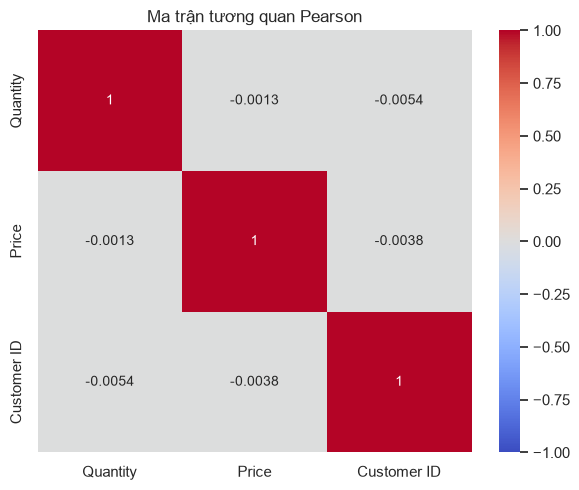

In [ ]:
num_df = df.select_dtypes(include=[np.number])
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Ma trận tương quan Pearson')
plt.tight_layout()
plt.show()


### Giai thich kinh doanh:

- **Quantity ↔ Price:** tuong quan gan 0 (-0.0013) → **khong co volume discount ro ret** trong dataset.  
- **Customer ID vs Quantity/Price:** gan 0 → Customer ID chi la khoa, khong co tuong quan dinh tinh nghia nghiep vu.  
- **Khong co bien muc tieu (target) ro ret** de train model → can tao feature (TotalAmount, return_flag) truoc khi model.

## 8. De xuat cac buoc cleaning (Proposed Cleaning Pipeline)

### Buoc 1: Tach loai giao dich
- Tach `Invoice` prefix `C` → bang `returns` (tra/huy)  
- Giữ `Invoice` khong co `C` → bang `sales` (ban thuan)  

### Buoc 2: Xu ly Missing Customer ID
- **Option A (BI):** Gan `Customer_ID = 'GUEST_<Invoice>'` cho dong NaN → van giu doanh thu, nhung khong dung cho RFM/CLV  
- **Option B (ML):** Drop dong NaN khi train model can customer (RFM, churn, CLV) — mat ~23% dong  
- **Khuyen nghi:** Tao cot `is_guest = Customer ID.isna()`; tach 2 luong xu ly  

### Buoc 3: Xu ly Price <= 0
- Loc `Price <= 0` (POSTAGE, adjustment, test) → tao bang `adjustments` rieng  
- Chi giữ `Price > 0` cho bang `sales`  

### Buoc 4: Outlier Detection & Treatment
- **Quantity extreme:** > 10,000 hoac < -10,000 → flag B2B/error, giu nhung can remove outlier khi train  
- **Price extreme:** > 18 (99th percentile) → kiem tra, co the la luxury/B2B  
- Dung IQR hoac Isolation Forest de automated flagging  

### Buoc 5: Deduplication
- Drop full-row duplicates (`df.drop_duplicates()`)  
- Kiem tra business-key dup: neu cung `Invoice+StockCode` nhung `Quantity/Price` khac → investigate manual  

### Buoc 6: Feature Engineering cho AI/BI
- `TotalAmount = Quantity * Price` (dong level)  
- `InvoiceMonth`, `InvoiceWeek`, `InvoiceDayOfWeek`, `IsWeekend`  
- `CustomerTenure` (days since first order)  
- `IsReturn = Quantity < 0`  
- `ProductCategory` tu `StockCode` prefix hoac NLP tren `Description`  

### Buoc 7: Schema chuan hoa (Star Schema cho BI)
- **Fact_Sales:** Invoice, StockCode, CustomerID, DateKey, Quantity, UnitPrice, TotalAmount, IsReturn  
- **Dim_Customer:** CustomerID, Country, FirstOrderDate, Segment (RFM)  
- **Dim_Product:** StockCode, Description, Category, UnitCost (neu co)  
- **Dim_Date:** DateKey, Year, Quarter, Month, Week, DayOfWeek, IsHoliday

## 9. Tong ket (Executive Summary)

### Cac phat hien chinh (Key Findings)

1. **Quy mo:** 1.07M dong giao dich, 2 nam (12/2009-12/2011), 9 cot goc.  
2. **Phan bo quoc gia:** UK chiem 91.9%, phan con lai phan tan (EIRE, DE, FR, AU...).  
3. **Khach hang:** ~5,942 khach co ID; **~23% dong khong co Customer ID** (khach vang lai).  
4. **Tra hang:** ~1.83% dong co Invoice prefix `C` (credit note), Quantity am.  
5. **Gia:** Co dong `Price <= 0` (~0.58%) — phu phi ship, adjustment, test.  
6. **San pham:** ~5,305 SKU unique; Description giau ngu nghia cho NLP.  
7. **Trung lap:** Full-row dup thap (1.14%); business-key dup (4.30%) can kiem tra them.  

### Van de chat luong du lieu (Data Quality Issues)

| Van de | Muc do | Tac dong |
|--------|--------|----------|
| Missing Customer ID (~23%) | **Cao** | Khong tinh duoc RFM/CLV cho 1/4 du lieu; bias segmentation |
| Price <= 0 / POSTAGE lines | **Trung binh** | Lam meo doanh thu, margin neu khong tach |
| Cancelled invoices mixed in | **Cao** | Double-count neu khong tach sale vs return |
| Quantity outliers (80,995, -80,995) | **Trung binh** | Skew mean/std; can flag B2B vs error |
| Description co typo/inconsistent | **Thap** | Gay noise cho NLP/product clustering |
| Khong co cot Cost/Profit | **Cao** | Khong tinh duoc margin thuc — can du lieu bo sung |

### Phu hop cho du an AI_BI_DASHBOARD

| Phân loại | Khả năng đáp ứng | Nội dung / Chi tiết |
| :--- | :--- | :--- |
| **Sales Dashboard** | Phù hợp | Doanh thu theo thời gian, quốc gia, sản phẩm — dữ liệu sạch sau làm sạch (cleaning). |
| **Customer Analytics** | Phù hợp | Phân tích RFM, Phân đoạn khách hàng (Segmentation), Giá trị vòng đời (CLV): Có mã khách hàng (Customer ID) cho 77% số dòng, lịch sử 2 năm đủ dài. |
| **Product Performance** | Phù hợp | Top/bottom SKU, bán kèm/bán chéo (cross-sell trên cùng Invoice), tính mùa vụ (seasonality). |
| **Forecasting** | Phù hợp | Chuỗi thời gian 2 năm, độ chi tiết theo ngày — phù hợp cho Prophet, ARIMA, LSTM. |
| **Geographic Analysis** | Phù hợp | 43 quốc gia, so sánh thị trường UK vs non-UK. |
| **Return Rate Analysis** | Phù hợp | Mẫu hình hóa đơn giảm trừ (Credit note pattern) rõ rệt — tính toán KPI chỉ số trả hàng (return rate). |
| **Profit / Margin Dashboard** | Không phù hợp / Cần bổ sung | Thiếu cột chi phí (Cost/COGS) — không tính được lợi nhuận thực tế. |
| **Inventory / Stockout** | Không phù hợp / Cần bổ sung | Không có dữ liệu mức tồn kho (stock level), thời gian ứng hàng (lead time), nhà cung cấp (supplier). |
| **Marketing Attribution** | Không phù hợp / Cần bổ sung | Không có thông tin kênh (channel), chiến dịch (campaign), UTM, nguồn giới thiệu (referral source). |
| **Customer Demographics** | Không phù hợp / Cần bổ sung | Không có tuổi, giới tính, thâm niên (chỉ có Quốc gia + Mã khách hàng). |
| **Real-time / Ops** | Không phù hợp / Cần bổ sung | Dữ liệu dạng lô theo lịch sử (batch operations), không có phát trực tuyến (streaming). |
| **B2B vs B2C Separation** | Không phù hợp / Cần bổ sung | Không có cờ (flag) phân loại kênh bán; số lượng lớn chỉ có thể suy đoán là bán buôn (wholesale). |

### Khuyen nghi uu tien (Business Priority)

1. **Clean & Split:** Tach sale/return, xu ly missing Customer ID, drop POSTAGE/Price<=0  
2. **Build Star Schema:** Fact + Dim tables → Power BI / Tableau / Superset ready  
3. **RFM + Cohort:** Chay ngay tren 77% co Customer ID → segment Champions/Loyal/At-risk  
4. **Demand Forecasting:** Aggregate daily/weekly per SKU → Prophet baseline  
5. **Enrich Cost Data:** Yeu cau team Finance/ERP cung cap Cost per SKU de mo rong Margin Dashboard  
6. **NLP Product Clustering:** Dung Description → auto-tag category, similarity search

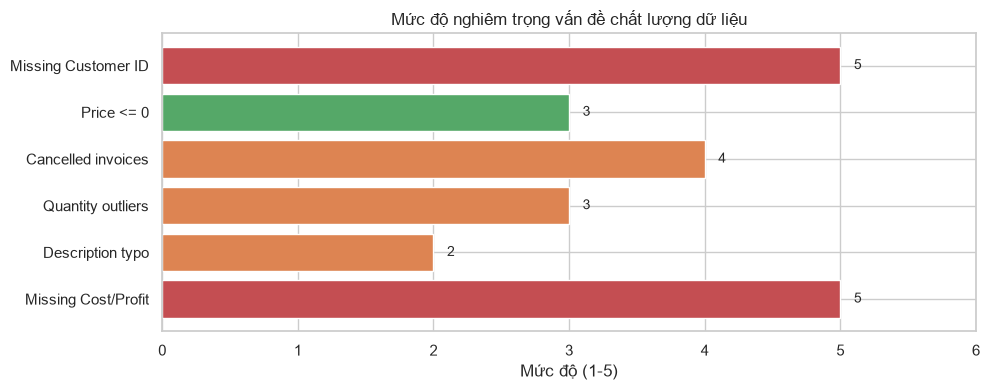

In [10]:
# Summary chart: data quality issues severity
issues = ['Missing Customer ID', 'Price <= 0', 'Cancelled invoices', 'Quantity outliers', 'Description typo', 'Missing Cost/Profit']
severity = [5, 3, 4, 3, 2, 5]  # 1-5 scale

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(issues[::-1], severity[::-1], color=['#C44E52','#DD8452','#DD8452','#DD8452','#55A868','#C44E52'])
ax.set_title('Mức độ nghiêm trọng vấn đề chất lượng dữ liệu')
ax.set_xlabel('Mức độ (1-5)')
ax.set_xlim(0, 6)
for i, v in enumerate(severity[::-1]):
    ax.text(v + 0.1, i, str(v), va='center')
plt.tight_layout()
plt.show()


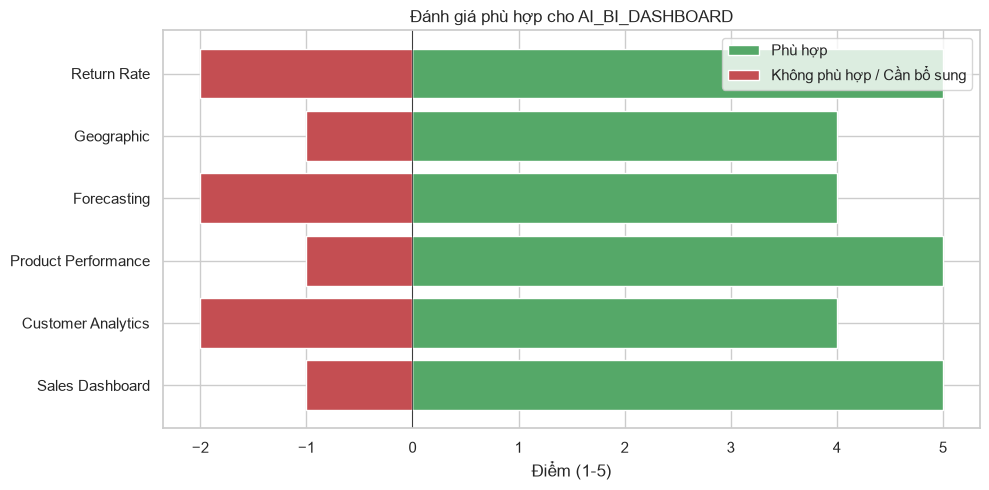

In [11]:
# Summary chart: suitability for AI_BI_DASHBOARD
suitability = ['Sales Dashboard', 'Customer Analytics', 'Product Performance', 'Forecasting', 'Geographic', 'Return Rate']
scores = [5, 4, 5, 4, 4, 5]
gaps = ['Margin Dashboard', 'Inventory', 'Marketing', 'Demographics', 'Real-time', 'B2B flag']
gap_scores = [1, 2, 1, 2, 1, 2]

fig, ax = plt.subplots(figsize=(10, 5))
y_pos = np.arange(len(suitability))
ax.barh(y_pos, scores, color='#55A868', label='Phù hợp')
ax.barh(y_pos, [-g for g in gap_scores], color='#C44E52', label='Không phù hợp / Cần bổ sung')
ax.set_yticks(y_pos)
ax.set_yticklabels(suitability)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title('Đánh giá phù hợp cho AI_BI_DASHBOARD')
ax.set_xlabel('Điểm (1-5)')
ax.legend()
plt.tight_layout()
plt.show()
